In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df= pd.read_csv("insurance.csv")

In [4]:
df.shape #entries and the colums

(1340, 10)

In [5]:
#set up for seaborn and such
pd.set_option("display.float_format","{:.2f}".format)

In [6]:

sns.set(style="whitegrid",palette="Set2",font_scale=1.1)


In [7]:
df.duplicated().sum() #check duplicates
# duplicate gives boolean on each row
#,sum gives us just an integer and it gives us howmany it has

0

In [8]:
df.isna().sum().sum()
#gives by cell then .sum is total in each col if we add another sum gives ttal of taotal
#gives whats missing


8

In [9]:
df.dropna(inplace=True)
#if false it doesnt change the og but we want it changed permanetly do we say true
df.isna().sum()

Id               0
age              0
gender           0
bmi              0
bloodpressure    0
diabetic         0
children         0
smoker           0
region           0
claim            0
dtype: int64

In [10]:

df.describe(include="all") #similar to summary in R
#include all includes caragorical ones too



,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
count,1332.00,1332.00,1332,1332.00,1332.00,1332,1332.00,1332,1332,1332.00
unique,NaN,NaN,2,NaN,NaN,2,NaN,2,4,NaN
top,NaN,NaN,male,NaN,NaN,No,NaN,No,southeast,NaN
freq,NaN,NaN,670,NaN,NaN,695,NaN,1058,442,NaN
mean,674.47,38.09,NaN,30.66,94.19,NaN,1.10,NaN,NaN,13325.25
std,384.70,11.11,NaN,6.12,11.45,NaN,1.21,NaN,NaN,12109.62
min,1.00,18.00,NaN,16.00,80.00,NaN,0.00,NaN,NaN,1121.87
25%,341.75,29.00,NaN,26.20,86.00,NaN,0.00,NaN,NaN,4760.16
50%,674.50,38.00,NaN,30.35,92.00,NaN,1.00,NaN,NaN,9412.97
75%,1007.25,47.00,NaN,34.73,99.00,NaN,2.00,NaN,NaN,16781.33


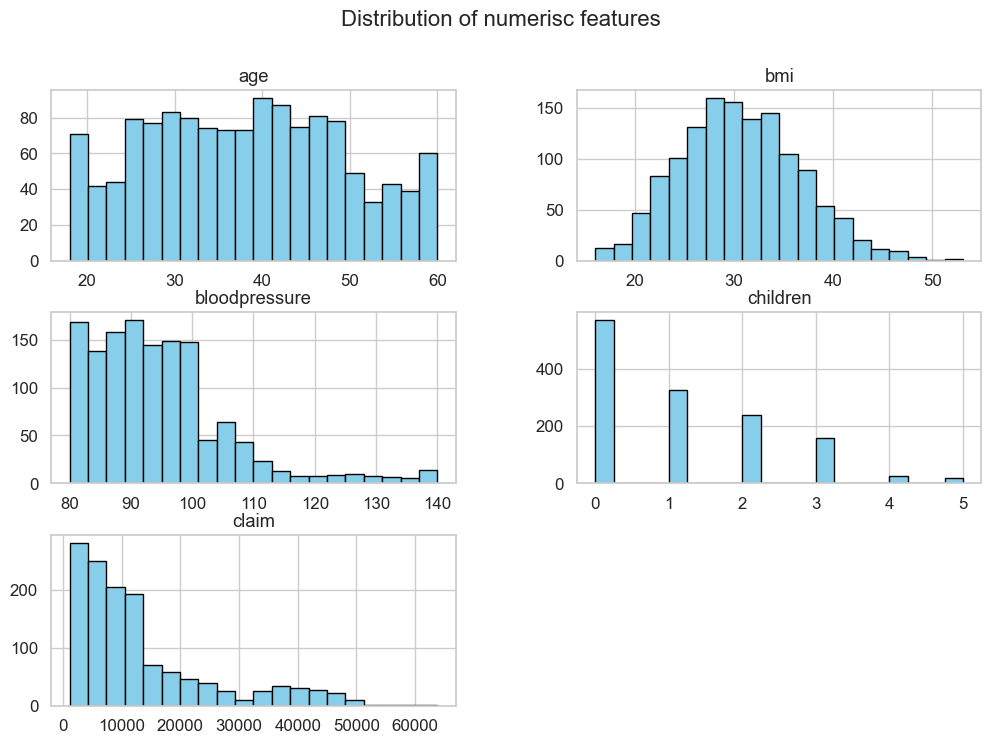

In [11]:
from turtle import color


numeric_cols=["age","bmi","bloodpressure","children","claim"]
df[numeric_cols].hist(bins=20,figsize=(12,8),color="skyblue",
edgecolor="black")
plt.suptitle("Distribution of numerisc features", fontsize=16)
plt.show()


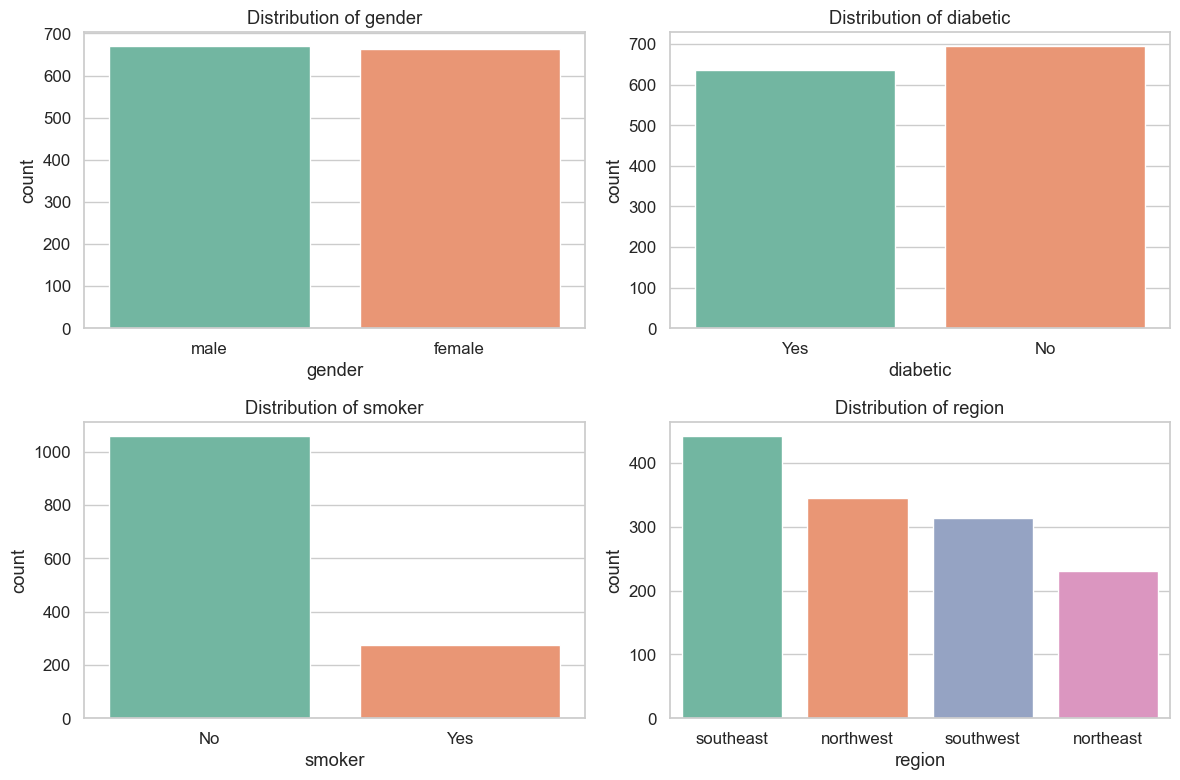

In [12]:

cat_cols=["gender","diabetic","smoker","region"]
plt.figure(figsize=(12,8))

for i, col in enumerate(cat_cols,1):
    plt.subplot(2,2,i) #neat organization
    sns.countplot(data=df,x=col)
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

In [13]:
#exploring key factor by pandsas
df.groupby(["gender","smoker"])["claim"].mean().round(2)
#so its [column, colums] for combinations
#then [ subject of  calculation].mean().round(2)

gender  smoker
female  No        8762.30
        Yes      30679.00
male    No        8169.25
        Yes      33042.01
Name: claim, dtype: float64

<Axes: title={'center': 'Average claim by gender and smoker status'}, xlabel='gender', ylabel='claim'>

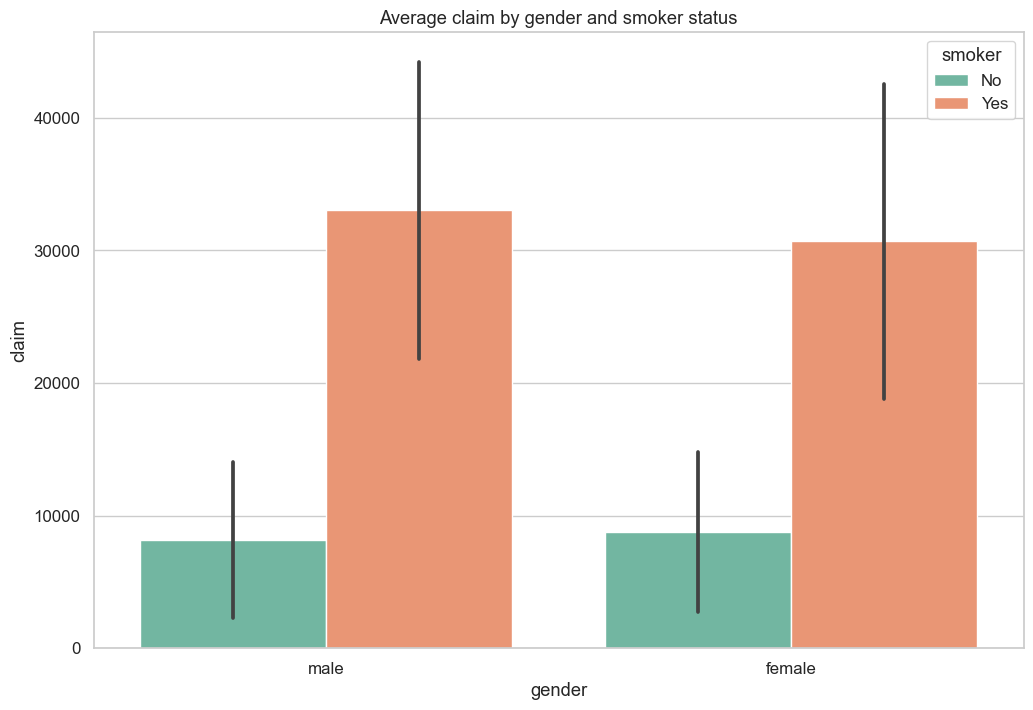

In [14]:
plt.figure(figsize=(12,8))
plt.title("Average claim by gender and smoker status")
sns.barplot(
    data=df,
    x="gender",y="claim",
    hue="smoker",estimator="mean",
    errorbar="sd")





In [15]:
pivot_region_diabetic=df.groupby(["region","diabetic"])["claim"].mean().unstack() 



In [16]:

pivot_region_diabetic

diabetic,No,Yes
region,,
northeast,16966.86,16818.30
northwest,11442.83,12224.96
southeast,13578.72,12574.09
southwest,13069.91,12313.74


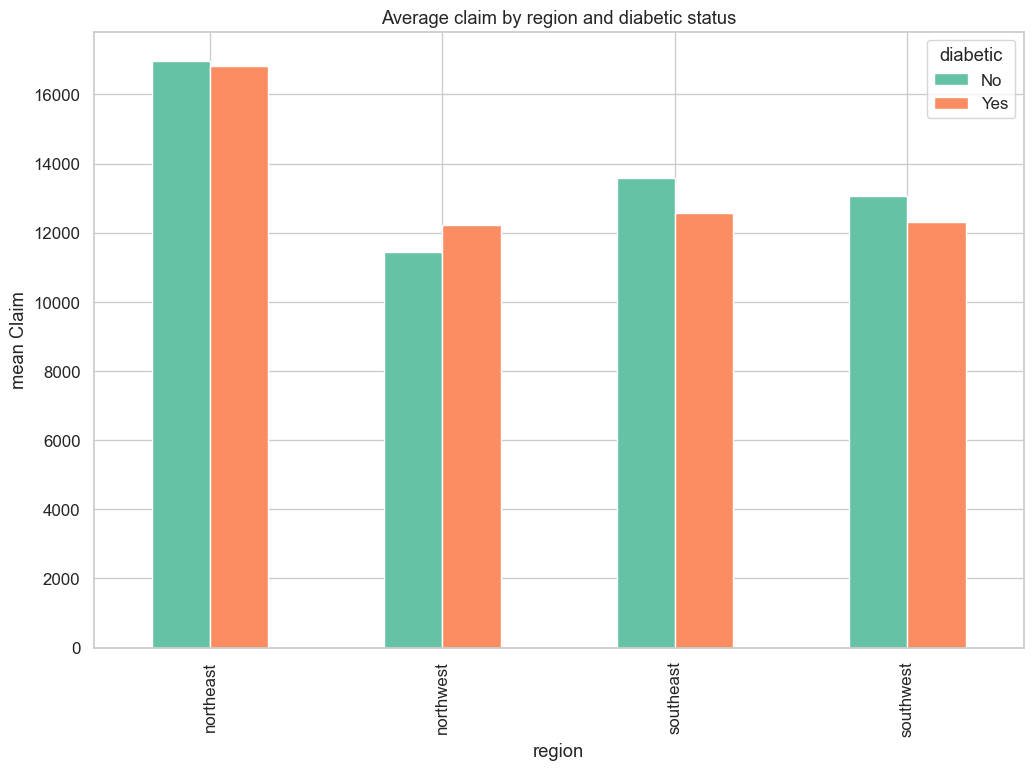

In [17]:
pivot_region_diabetic.plot(kind="bar",figsize=(12,8))
plt.title("Average claim by region and diabetic status")
plt.ylabel("mean Claim") # mind spelling of label its not lable
plt.show()


In [18]:
pivot_table=pd.pivot_table(df,values="claim",index="region",columns="smoker",aggfunc="mean")
pivot_table

smoker,No,Yes
region,,
northeast,11666.11,29673.54
northwest,8076.20,30192.00
southeast,7444.14,34845.00
southwest,8294.75,32269.06


In [19]:
pivot_table=pd.pivot_table(df,values="claim",index="children",columns="diabetic",aggfunc="mean")
pivot_table

diabetic,No,Yes
children,,
0,12967.40,11985.29
1,12730.46,12732.06
2,15567.77,14579.36
3,13807.61,17091.26
4,14106.63,13573.35
5,8519.04,9205.59


In [20]:
df[numeric_cols].corr()
#df[] shows all the colums we want to see
#whu]ke recular call shows colums


,age,bmi,bloodpressure,children,claim
age,1.00,-0.04,-0.06,-0.03,-0.03
bmi,-0.04,1.00,0.14,0.01,0.20
bloodpressure,-0.06,0.14,1.00,-0.03,0.53
children,-0.03,0.01,-0.03,1.00,0.06
claim,-0.03,0.20,0.53,0.06,1.00


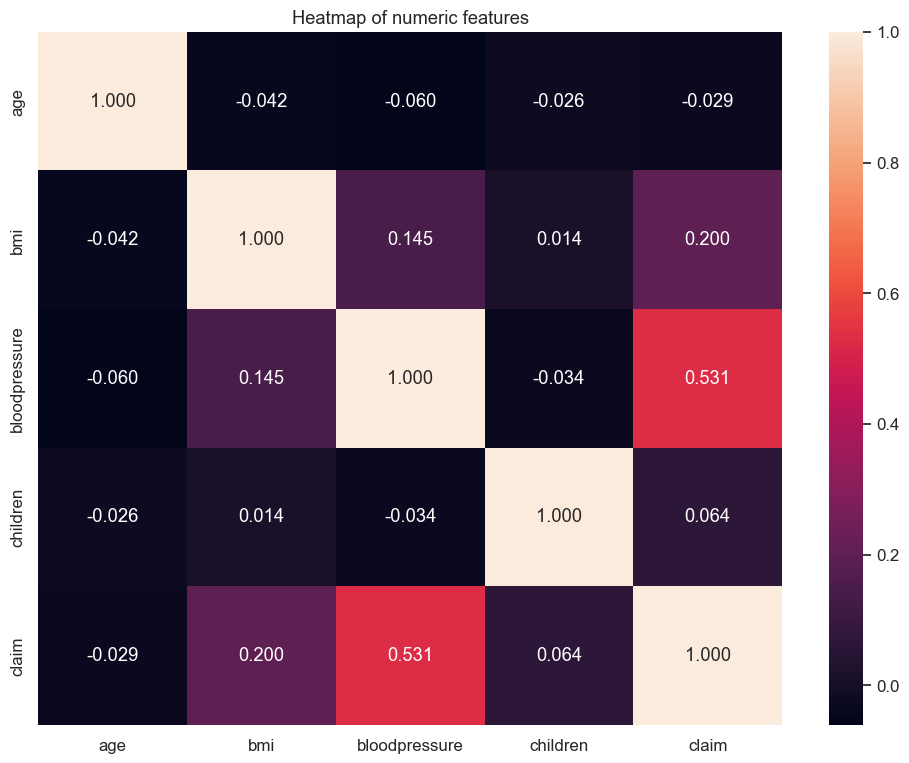

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df[numeric_cols].corr(), annot=True,fmt=".2f",cmap="coolwarm")
plt.title("Heatmap of numeric features")
plt.show()

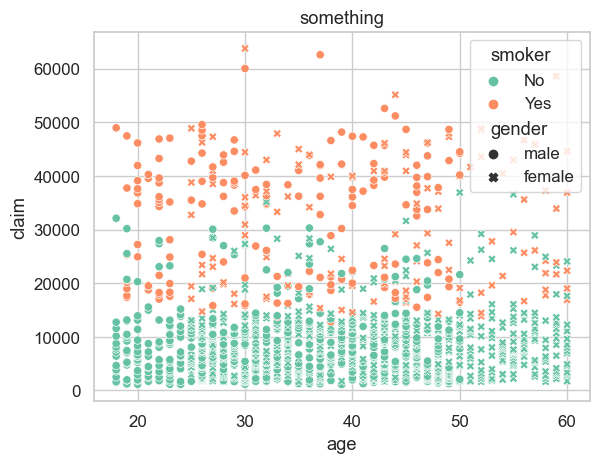

In [ ]:
sns.scatterplot(df, x="age",y="claim",hue="smoker", style="gender")
plt.title("Claim Vs Age by smoker status")
plt.show()


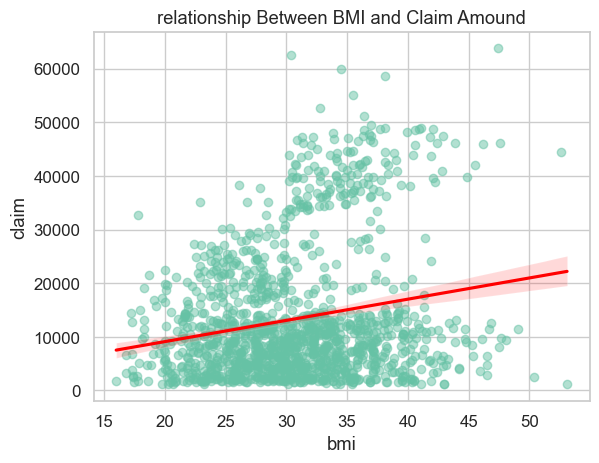

In [39]:
sns.regplot(df,x="bmi",y="claim",scatter_kws={"alpha":.5},line_kws={"color":"red"}) 
plt.title("relationship Between BMI and Claim Amound")
plt.show()

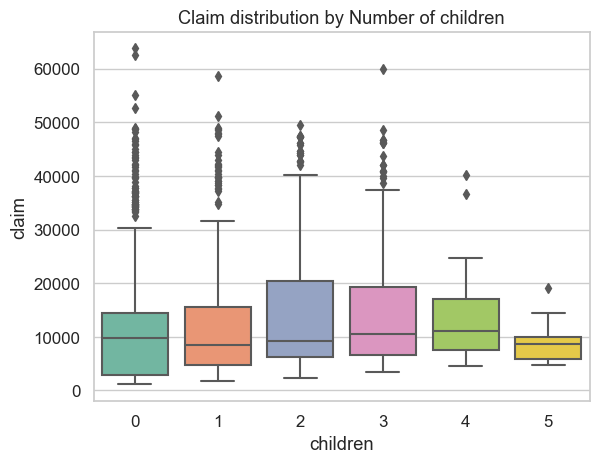

In [43]:
sns.boxplot(df,x="children",y="claim")
plt.title("Claim distribution by Number of children")
plt.show()

In [53]:

df["age_group"]=pd.cut(df["age"],
bins=[0,18,30,45,60,100],
labels=["<18","18-30","31-45","46-60","60+"])

In [61]:
df["age_group"].value_counts()

age_group
31-45    553
46-60    383
18-30    380
<18       16
60+        0
Name: count, dtype: int64

<Axes: xlabel='age_group', ylabel='claim'>

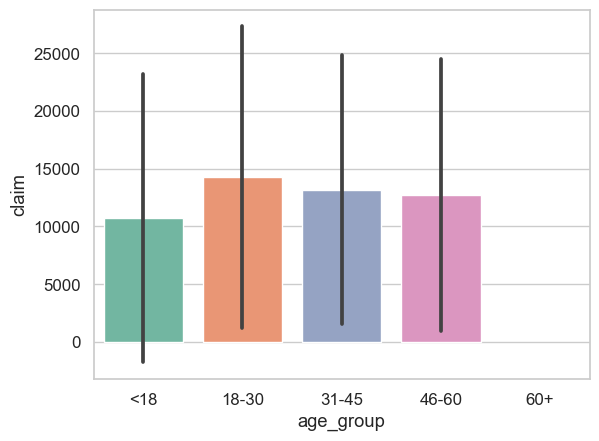

In [67]:
sns.barplot(data=df,x="age_group",y="claim",estimator="mean",errorbar="sd")
#boxplot doesnt have a estimator function 

In [71]:
df["bmi_category"]=pd.cut(df["bmi"],
bins=[0,18.5,24.9,29.9,100],
labels=["underweight","Normalweight","Overweight","Obese"])

<Axes: xlabel='age_group'>

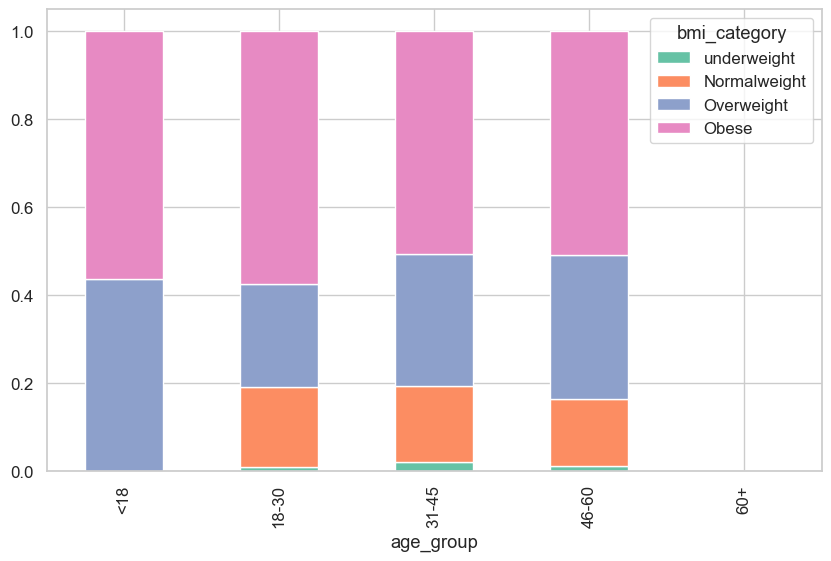

In [86]:
# Grouped bar chart is better for comparing counts across categories
# Shows what % of each age group falls into which BMI category
counts = df.groupby(["age_group","bmi_category"]).size().unstack()
proportions = counts.div(counts.sum(axis=1), axis=0,)
proportions.plot(kind="bar", stacked=True,figsize=(10,6))


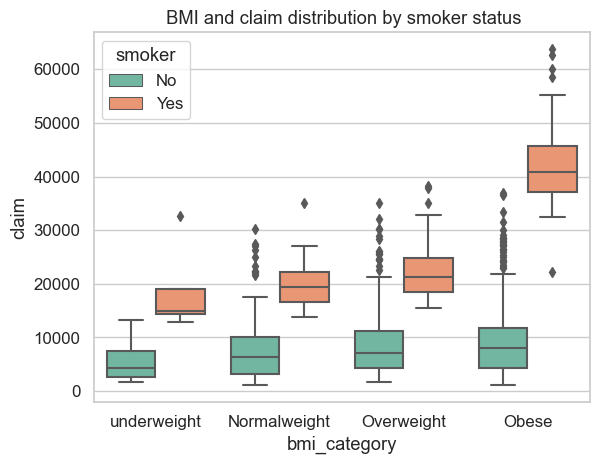

In [88]:
sns.boxplot(df,x="bmi_category", y="claim",hue="smoker")
plt.title(" BMI and claim distribution by smoker status")
plt.show()


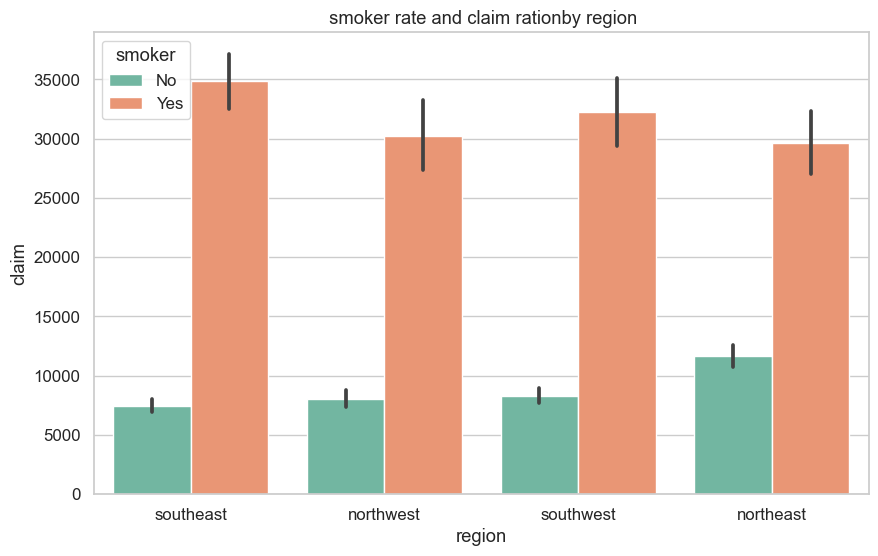

In [98]:
#moker rate and claim ratio by region
plt.figure(figsize=(10,6))
sns.barplot(df,x="region",y="claim",hue="smoker")
plt.title(" smoker rate and claim rationby region")
plt.show()

In [104]:
region_stat=df.groupby("region").agg(
    smoker_rate=("smoker", lambda x:(x=="Yes").mean()*100), #lambda is like a function to choose x where its yes(smoker)
    mean_claim= ("claim","mean")
).reset_index()

In [106]:
region_stat

,region,smoker_rate,mean_claim
0,northeast,29.00,16889.04
1,northwest,16.81,11794.22
2,southeast,20.59,13085.50
3,southwest,18.47,12723.13


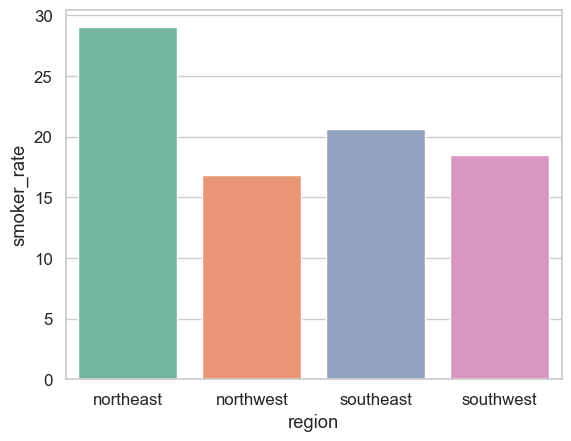

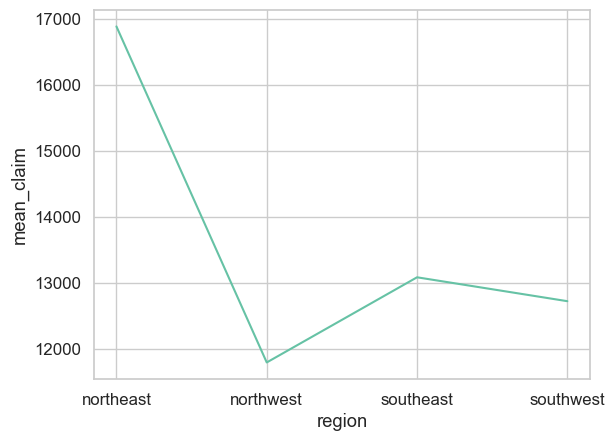

In [ ]:
sns.barplot(region_stat,x="region",y="smoker_rate")
plt.show()
sns.lineplot(region_stat, x="region", y="mean_claim")
plt.show()

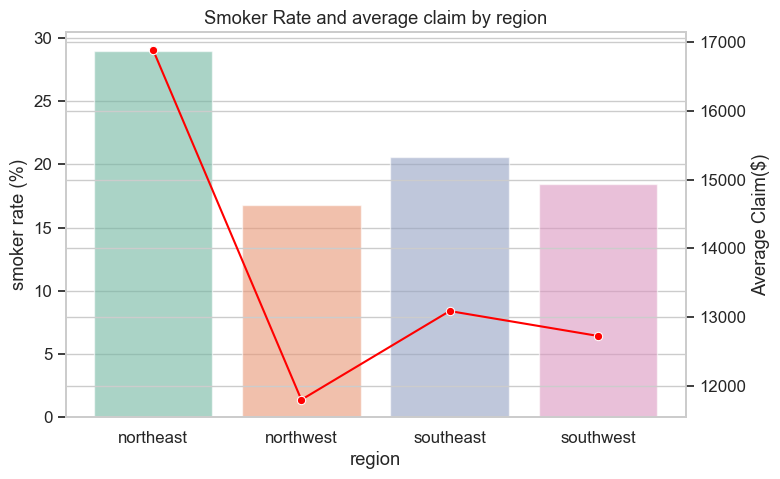

In [129]:
# now we over lay them
fig,ax1=plt.subplots(figsize=(8,5))
sns.barplot(region_stat,x="region",y="smoker_rate", ax=ax1, alpha=.6)
ax2=ax1.twinx()
sns.lineplot(region_stat, x="region", y="mean_claim",ax=ax2, color="red", marker="o")

ax1.set_ylabel("smoker rate (%)")
ax2.set_ylabel("Average Claim($)")
plt.title("Smoker Rate and average claim by region")
plt.show()

In [1]:
#data preprocessing and preparation 
from sklearn.model_selection import train_test_split # for split into test and train set 
from sklearn.preprocessing import LabelEncoder,StandardScaler # categorical cols  and  scaling function
import joblib # to export the encoders in this notebook

In [6]:
df.columns


Index(['Id', 'age', 'gender', 'bmi', 'bloodpressure', 'diabetic', 'children',
       'smoker', 'region', 'claim'],
      dtype='object')

In [7]:
X=df[["age","gender","bmi","bloodpressure","children","smoker"]] #use these as variables to predict the claim
Y=df[["claim"]] #what we are predicting

,age,gender,bmi,bloodpressure,children,smoker
0,39.0,male,23.2,91,0,No
1,24.0,male,30.1,87,0,No
2,NaN,male,33.3,82,0,No
3,NaN,male,33.7,80,0,No
4,NaN,male,34.1,100,0,No
...,...,...,...,...,...,...
1335,44.0,female,35.5,88,0,Yes
1336,59.0,female,38.1,120,1,Yes
1337,30.0,male,34.5,91,3,Yes
1338,37.0,male,30.4,106,0,Yes


In [9]:
cat_cols=["gender","smoker","diabetic"]
label_encoders={}

In [10]:
for col in cat_cols:
    le=LabelEncoder()
    X[col]=le.fit_transform(X[col])
    label_encoders[col]=le

    joblib.dump(label_encoders,"label_encoders.pkl")



C:\Users\neba_\AppData\Local\Temp\ipykernel_21736\678618287.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col]=le.fit_transform(X[col])
C:\Users\neba_\AppData\Local\Temp\ipykernel_21736\678618287.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col]=le.fit_transform(X[col])


KeyError: 'diabetic'